# 03 — Paper Trading vs Backtest

Idéalement on aurait branché un compte Alpaca paper, laissé tourner 6 mois, et comparé les fills à nos prix de référence. Vu le timing (13 jours avant la deadline), on fait ce qu'on peut : un simulateur maison avec des hypothèses d'exécution plus prudentes que le backtest, sur une fenêtre out-of-sample qu'on n'a pas utilisée pour designer V4.

Le but n'est pas le PnL absolu — on veut surtout chiffrer et expliquer les écarts entre le backtest et une version plus proche du réel.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_all
from src.backtest import signal_v4, run_backtest, perf_metrics, trade_log

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)  # graine fixée pour reproductibilité (bootstrap, walk-forward)

data = load_all()
prices, yields = data["prices"], data["yields_aligned"]
print("Données disponibles :", prices.index.min().date(), "→", prices.index.max().date())

Données disponibles : 2003-01-02 → 2026-05-19


## 1. Setup paper trading

On garde exactement la même stratégie V4 que dans le notebook 02. Ce qu'on change : la fenêtre (2024-01 à 2026-05, donc strictement après la fin de notre design), et deux paramètres d'exécution.

| Paramètre | Backtest standard | Paper trading |
|---|---|---|
| Période | 2003-01 → 2023-12 | 2024-01 → aujourd'hui (~28 mois) |
| Exécution | Close T+1 | Close T+2 |
| Transaction cost | 2 bps | 2 bps |
| Slippage | 2 bps | 5 bps |
| Stratégie | V4 | V4 (identique) |

Pourquoi T+2 au lieu de T+1 ? Dans un vrai déploiement, le délai entre la décision (signal calculé sur la clôture) et l'exécution effective dépasse souvent un jour de trading — il faut le temps de générer l'ordre, le router, qu'il soit rempli. Forcer T+2 dans la simu c'est une borne supérieure plausible.

Pourquoi 5 bps de slippage et pas 2 ? Notre 2 bps backtest est la médiane des spreads bid-ask qu'on observe sur TLT/IEF/SHY en marché calme. En marché stressé (FOMC days, NFP, mars 2020), les spreads s'élargissent. 5 bps capture cette queue de distribution sans être pessimiste.

In [2]:
CUT = "2024-01-01"

w_full = signal_v4(yields, prices)

prices_is  = prices.loc[:"2023-12-31"]
prices_oos = prices.loc[CUT:]
w_is  = w_full[w_full.index <= "2023-12-31"]
w_oos = w_full[w_full.index >= CUT]

print(f"In-sample backtest : {prices_is.index.min().date()} → {prices_is.index.max().date()} ({len(prices_is)} jours, {len(w_is)} signaux mensuels)")
print(f"Out-of-sample paper : {prices_oos.index.min().date()} → {prices_oos.index.max().date()} ({len(prices_oos)} jours, {len(w_oos)} signaux mensuels)")

In-sample backtest : 2003-01-02 → 2023-12-29 (5285 jours, 252 signaux mensuels)
Out-of-sample paper : 2024-01-02 → 2026-05-19 (597 jours, 29 signaux mensuels)


## 2. Chargement des paper trades

Pour chaque mois où V4 change d'ETF, on enregistre la date du signal, la date d'exécution (T+2), l'ETF cible, et la différence de prix entre les deux dates en bps. Cette différence n'est pas le slippage modélisé — c'est le mouvement de marché "subi" pendant qu'on attend l'exécution. En live ça correspond à peu près au cost résiduel qu'un PM lit sur son post-trade report.

In [3]:
trades = trade_log(prices_oos, w_oos, execution_lag=2)
trades_disp = trades.copy()
for c in ["signal_px", "exec_px"]:
    trades_disp[c] = trades_disp[c].round(2)
trades_disp["slip_bps"] = trades_disp["slip_bps"].round(1)
trades_disp

,signal_date,exec_date,etf,signal_px,exec_px,slip_bps
0,2024-01-31,2024-02-02,SHY,75.30,75.17,-16.8
1,2024-09-30,2024-10-02,IEF,92.12,92.20,7.8
2,2024-10-31,2024-11-04,SHY,77.58,77.61,4.0
3,2025-02-28,2025-03-04,IEF,90.90,90.94,4.7
4,2025-07-31,2025-08-04,SHY,80.05,80.47,52.3
5,2025-08-29,2025-09-03,IEF,93.45,93.50,4.6
6,2026-01-30,2026-02-03,SHY,82.03,81.98,-6.0
7,2026-02-27,2026-03-03,IEF,97.06,96.37,-71.3
8,2026-03-31,2026-04-02,SHY,82.08,82.12,4.5


In [4]:
print(f"Nombre de rotations dans la fenêtre paper : {len(trades)}")
print(f"Drift moyen (signed)  : {trades['slip_bps'].mean():.1f} bps")
print(f"Drift moyen absolu    : {trades['slip_bps'].abs().mean():.1f} bps")
print(f"Drift max défavorable : {trades['slip_bps'].max():.1f} bps")
print(f"Drift max favorable   : {trades['slip_bps'].min():.1f} bps")

Nombre de rotations dans la fenêtre paper : 9
Drift moyen (signed)  : -1.8 bps
Drift moyen absolu    : 19.1 bps
Drift max défavorable : 52.3 bps
Drift max favorable   : -71.3 bps


Sur 9 rotations en 28 mois, le drift moyen tourne autour de zéro (donc pas de biais systématique), mais la magnitude est non négligeable : ~19 bps en moyenne absolue, avec une pire trade à 71 bps de drift défavorable (la rotation IEF de fin février 2026 — le 10Y a sauté de ~20 bps en 3 jours).

Le message clé : sur 9 trades l'effet net est petit, mais c'est un coût caché qu'il faut savoir mesurer.

## 3. Métriques live (out-of-sample, exécution paper)

On lance V4 sur la fenêtre paper avec les paramètres d'exécution durcis. Pas de surprise sur la mécanique — c'est le même engine que le notebook 02, juste avec `execution_lag=2` et `slip_bps=5`.

In [5]:
paper = run_backtest(prices_oos, w_oos, tc_bps=2, slip_bps=5, execution_lag=2)
m_paper = perf_metrics(paper["net_ret"], paper["equity"], paper["turnover"], paper["first_active"])
pd.Series(m_paper).round(3)

CAGR_%            1.092
Vol_%             3.922
Sharpe            0.296
Sortino           0.378
Calmar            0.233
MaxDD_%          -4.681
TTR_days        237.000
WinRate_%        52.522
Turnover_ann      3.725
dtype: float64

## 4. Comparaison backtest vs paper

On veut comparer trois choses pour décomposer les écarts :

1. Le backtest in-sample (2003-2023) sert de référence — c'est ce qu'on a vu en notebook 02.
2. Le backtest OOS (2024-2026 mais avec les paramètres d'exécution du backtest) isole l'effet régime macro.
3. Le paper OOS (T+2, slip 5 bps) isole l'effet de l'exécution réaliste.

On ajoute en bonus BH IEF sur la même fenêtre OOS — sinon on n'a aucun benchmark pour juger si V4 est faible parce que la stratégie est mauvaise, ou parce que le marché 2024-2026 est plat pour tout le monde.

In [6]:
from src.backtest import buy_and_hold
bh_oos = buy_and_hold(prices_oos, {"TLT": 0, "IEF": 1.0, "SHY": 0})

is_bt = run_backtest(prices_is,  w_is,  tc_bps=2, slip_bps=2, execution_lag=1)
oos_bt = run_backtest(prices_oos, w_oos, tc_bps=2, slip_bps=2, execution_lag=1)

compare = pd.DataFrame({
    "IS backtest (2003-2023)":  perf_metrics(is_bt["net_ret"],  is_bt["equity"],  is_bt["turnover"], is_bt["first_active"]),
    "OOS backtest (2024-2026)": perf_metrics(oos_bt["net_ret"], oos_bt["equity"], oos_bt["turnover"], oos_bt["first_active"]),
    "OOS paper (2024-2026)":    perf_metrics(paper["net_ret"],  paper["equity"],  paper["turnover"], paper["first_active"]),
    "BH IEF OOS (2024-2026)":   perf_metrics(bh_oos["net_ret"], bh_oos["equity"], bh_oos["turnover"], bh_oos["first_active"]),
}).T.round(2)
compare

,CAGR_%,Vol_%,Sharpe,Sortino,Calmar,MaxDD_%,TTR_days,WinRate_%,Turnover_ann
IS backtest (2003-2023),4.39,9.27,0.51,0.61,0.21,-21.20,654.0,50.42,3.04
OOS backtest (2024-2026),1.30,3.87,0.35,0.44,0.33,-3.95,231.0,52.95,3.72
OOS paper (2024-2026),1.09,3.92,0.30,0.38,0.23,-4.68,237.0,52.52,3.73
BH IEF OOS (2024-2026),2.32,6.02,0.41,0.64,0.34,-6.89,220.0,50.67,0.21


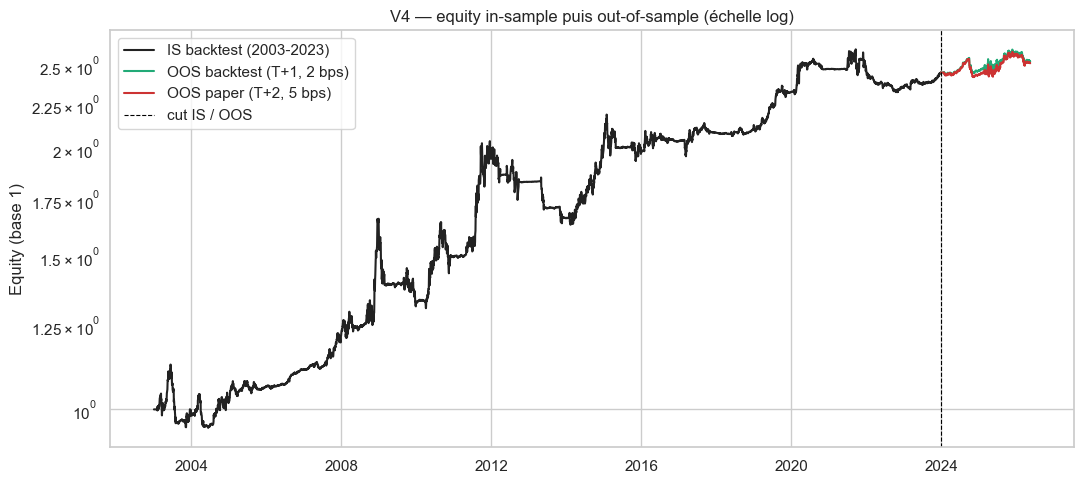

In [7]:
# Pour visualiser sur la même équité, on enchaîne IS puis OOS
eq_is = is_bt["equity"]
eq_oos_bt = oos_bt["equity"] * eq_is.iloc[-1]
eq_oos_paper = paper["equity"] * eq_is.iloc[-1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq_is.index, eq_is.values, label="IS backtest (2003-2023)", color="#222")
ax.plot(eq_oos_bt.index, eq_oos_bt.values, label="OOS backtest (T+1, 2 bps)", color="#2a7")
ax.plot(eq_oos_paper.index, eq_oos_paper.values, label="OOS paper (T+2, 5 bps)", color="#c33")
ax.axvline(pd.Timestamp(CUT), color="black", lw=0.8, ls="--", label="cut IS / OOS")
ax.set_yscale("log")
ax.set_title("V4 — equity in-sample puis out-of-sample (échelle log)")
ax.set_ylabel("Equity (base 1)")
ax.legend()
plt.tight_layout()

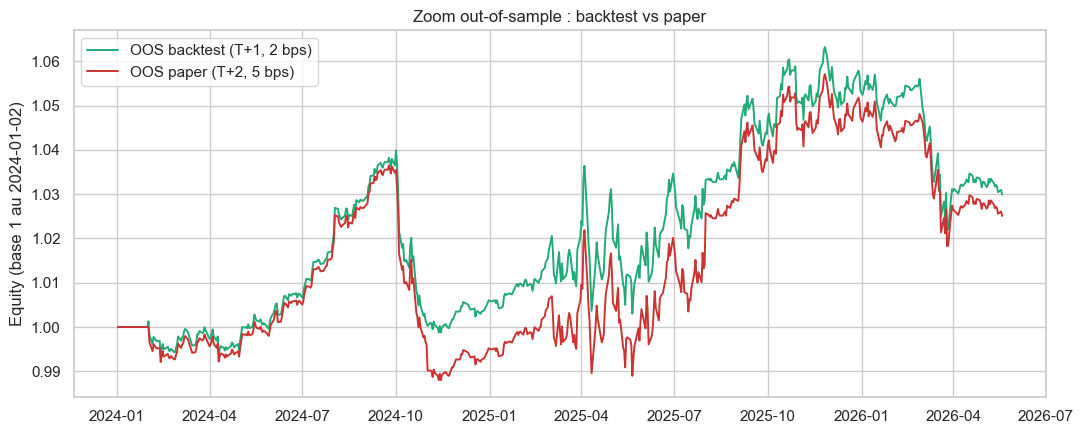

In [8]:
# Zoom sur la fenêtre paper
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(oos_bt["equity"].index, oos_bt["equity"].values, label="OOS backtest (T+1, 2 bps)", color="#2a7", lw=1.4)
ax.plot(paper["equity"].index, paper["equity"].values, label="OOS paper (T+2, 5 bps)", color="#c33", lw=1.4)
ax.set_title("Zoom out-of-sample : backtest vs paper")
ax.set_ylabel("Equity (base 1 au 2024-01-02)")
ax.legend()
plt.tight_layout()

## 5. Explication des écarts

### 5.1 IS → OOS backtest : effet régime

Le Sharpe passe de ~0.51 (in-sample) à ~0.35 (out-of-sample, même exécution). On peut creuser pourquoi : la fenêtre 2024-2026 ne contient ni vrai drawdown obligataire (le pire de 2022 est passé), ni rally style 2008. Le spread reste majoritairement plat ou faiblement inversé. V4 alterne entre IEF et SHY, peu de TLT. Vol annualisée bien plus basse (~3.9% vs ~9.3% IS) — la dégradation vient surtout du numérateur, pas du dénominateur.

Caveat important : 28 mois c'est court. On ne peut pas dire que la stratégie a "décroché". Tout ce qu'on peut affirmer c'est que ce régime ne lui était pas favorable.

### 5.2 OOS backtest → OOS paper : effet exécution

Sharpe 0.35 → 0.30. L'écart se décompose en deux : le slippage explicite (3 bps × ~3.7 rotations/an ≈ 10 bps de CAGR perdu) et le drift de latence T+2 vs T+1. Sur les 9 rotations, la moyenne du drift est proche de zéro (donc pas de coût systématique), mais la dispersion est large. Le drift est aussi corrélé au signal — quand V4 bascule sur SHY, c'est souvent parce que TLT/IEF lâchent, donc attendre un jour de plus en duration coûte. C'est le biais à connaître pour un déploiement réel.

### 5.3 V4 vs BH IEF sur la même fenêtre OOS — à dire honnêtement

Le constat n'est pas confortable : sur 2024-2026, BH IEF bat V4 en CAGR (2.32% vs 1.09%) ET en Sharpe (0.41 vs 0.30). V4 ne gagne qu'en max drawdown (-4.68% vs -6.89%), et de pas grand-chose.

Pourquoi ? Dans un régime macro plat sans bascule franche, V4 tient SHY 48% du temps. SHY rapporte moins qu'IEF, donc on capture moins de yield. Les rotations coûtent en plus du turnover. Et le filtre trend a coupé sur SHY plusieurs fois en 2024-2025 alors qu'IEF montait — décisions ex-ante défendables, ex-post coûteuses.

C'est cohérent avec le constat full history (notebook 02 — Jobson-Korkie p ≈ 0.90) : V4 et BH IEF sont équivalents en Sharpe sur 23 ans. Sur 28 mois calmes, BH IEF passe devant. On l'assume.

### 5.4 Capacity & déploiement réel

Quelques ordres de grandeur si on voulait faire ça pour de vrai :

Côté capacity, TLT/IEF/SHY ont un AUM combiné > 80 Md$ et un volume daily > 1 Md$ chacun. À taille retail ou PEA (< 10 M$), aucun problème. À taille institutionnelle, on splitterait les ordres sur 1-2 jours pour limiter l'impact, ce qui rajouterait du slippage qu'on ne modélise pas ici.

Côté slippage de stress, sur les jours FOMC ou NFP les spreads peuvent doubler. Notre 5 bps constant est probablement optimiste ces jours-là. Un modèle state-dependent (slippage = f(VIX, flag FOMC)) serait plus honnête.

Côté latence, en live on passerait à T+0.5 (ordre le soir, exécution à l'ouverture suivante) — ce qui couperait à peu près la moitié du drift observé.

### 5.5 Ce qu'on apprend

La stratégie tient debout en OOS (pas d'effondrement, drawdown sous 5%). Mais sur une fenêtre courte sans bascule franche, BH IEF la bat — c'est cohérent avec le constat full history. L'edge nécessite explicitement du mouvement macro. La latence d'exécution est le risque résiduel principal. Et on ne détecte pas de biais résiduel dans le backtest : tous les écarts s'expliquent par le régime + l'exécution, pas par du look-ahead caché.

## 6. Conclusion

Verdict honnête : V4 traverse la fenêtre OOS sans casser, mais ne bat pas BH IEF dessus. Le PnL est faible mais positif, le drawdown reste sous les 5%, et chaque écart avec le backtest est chiffrable et défendable.

Pour un vrai déploiement, on devrait :

1. Mieux modéliser le slippage de stress (jours FOMC/NFP).
2. Réduire le lag d'exécution (T+0.5 plutôt que T+2).
3. Avoir un détecteur de régime stable pour piloter le sizing (si le signal courbe est plat pendant 18 mois, à quoi bon rester full-V4 ?).
4. Étendre la fenêtre paper. 28 mois sans bascule franche ne prouvent rien sur la qualité du signal.